# Week 5: Exploratory Data Analysis and Operational Diagnostics

## Operational Diagnostics Investigation

### Objective

The objective of this analysis is to investigate operational performance using the provided Mystery Operations dataset. Through exploratory data analysis (EDA), anomaly detection, and diagnostic techniques such as drill-down analysis, Pareto analysis, and correlation analysis, this notebook aims to identify the root causes of operational issues and recommend actionable improvements for the operations team.

The analysis follows a structured investigation process:
- Data profiling
- Exploratory data analysis
- Anomaly detection
- Root cause analysis
- Business recommendations

## 1. Import Required Libraries

The first step is to import the Python libraries that will be used throughout the analysis.

- **Pandas** for loading and manipulating the dataset.
- **NumPy** for numerical operations.
- **Matplotlib** and **Seaborn** for data visualization.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

The Mystery Operations dataset is loaded into a Pandas DataFrame so that it can be explored and analyzed.

In [2]:
# Load dataset
df = pd.read_csv("Mystery_Ops.csv")

# Display first five records
df.head()

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none
1,MO-20261015-KIS-D,15/10/2026,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none
2,MO-20260518-MOM-D,18/05/2026,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none
3,MO-20260209-MOM-N,09/02/2026,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none
4,MO-20260318-MOM-N,18/03/2026,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none


## 3. Initial Exploration

Before analyzing the data, it is important to understand its structure, identify missing values, and check for duplicate records. This helps ensure the quality of subsequent analyses.

In [3]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2920, 11)

Columns:
['record_id', 'operation_date', 'depot', 'shift', 'operator_id', 'machine_id', 'throughput_barrels', 'temperature_c', 'maintenance_flag', 'voltage_count', 'incident_type']

Data Types:
record_id              object
operation_date         object
depot                  object
shift                  object
operator_id            object
machine_id             object
throughput_barrels    float64
temperature_c         float64
maintenance_flag        int64
voltage_count           int64
incident_type          object
dtype: object


In [4]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           2920 non-null   object 
 1   operation_date      2920 non-null   object 
 2   depot               2920 non-null   object 
 3   shift               2920 non-null   object 
 4   operator_id         2902 non-null   object 
 5   machine_id          2920 non-null   object 
 6   throughput_barrels  2915 non-null   float64
 7   temperature_c       2900 non-null   float64
 8   maintenance_flag    2920 non-null   int64  
 9   voltage_count       2920 non-null   int64  
 10  incident_type       2920 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 251.1+ KB


In [5]:
# Summary statistics
df.describe(include="all")

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
count,2920,2920,2920,2920,2902,2920,2915.000000,2900.000000,2920.000000,2920.000000,2920
unique,2920,365,4,2,15,13,NaN,NaN,NaN,NaN,4
top,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-E02,NBI-P03,NaN,NaN,NaN,NaN,none
freq,1,8,730,1460,253,566,NaN,NaN,NaN,NaN,2332
mean,NaN,NaN,NaN,NaN,NaN,NaN,916.891149,25.050310,0.186644,221.122945,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,168.122566,5.567664,0.389692,6.518187,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,296.500000,10.900000,0.000000,197.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,872.850000,21.200000,0.000000,217.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,969.300000,25.100000,0.000000,221.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1029.650000,29.100000,0.000000,225.000000,NaN


In [6]:
# Missing values
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage
record_id,0,0.00
operation_date,0,0.00
depot,0,0.00
shift,0,0.00
operator_id,18,0.62
machine_id,0,0.00
throughput_barrels,5,0.17
temperature_c,20,0.68
maintenance_flag,0,0.00
voltage_count,0,0.00


In [7]:
# Duplicate records
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


### Initial Findings

The dataset contains **2,920 operational records** across eleven variables describing production activities.

The initial assessment revealed a small number of missing values in the **operator_id**, **throughput_barrels**, and **temperature_c** columns. Since the proportion of missing data is very low, it is unlikely to significantly affect the analysis.

No duplicate records were identified, indicating that each operational record represents a unique observation.

## 4. Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution, identify unusual values, and summarize key characteristics. Numerical variables are visualized using histograms and box plots, while categorical variables are explored using frequency distributions and bar charts.

In [8]:
# Numerical columns
numerical_cols = [
    "throughput_barrels",
    "temperature_c",
    "voltage_count"
]

# Summary statistics
df[numerical_cols].describe()

,throughput_barrels,temperature_c,voltage_count
count,2915.000000,2900.000000,2920.000000
mean,916.891149,25.050310,221.122945
std,168.122566,5.567664,6.518187
min,296.500000,10.900000,197.000000
25%,872.850000,21.200000,217.000000
50%,969.300000,25.100000,221.000000
75%,1029.650000,29.100000,225.000000
max,1210.600000,39.900000,242.000000


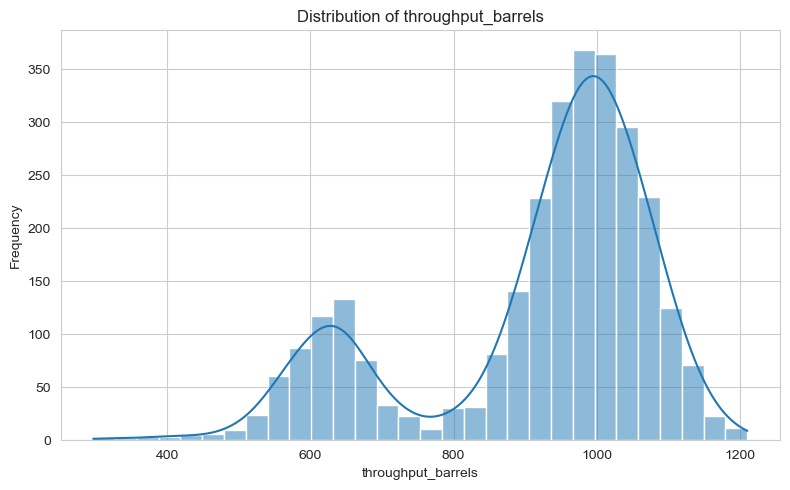

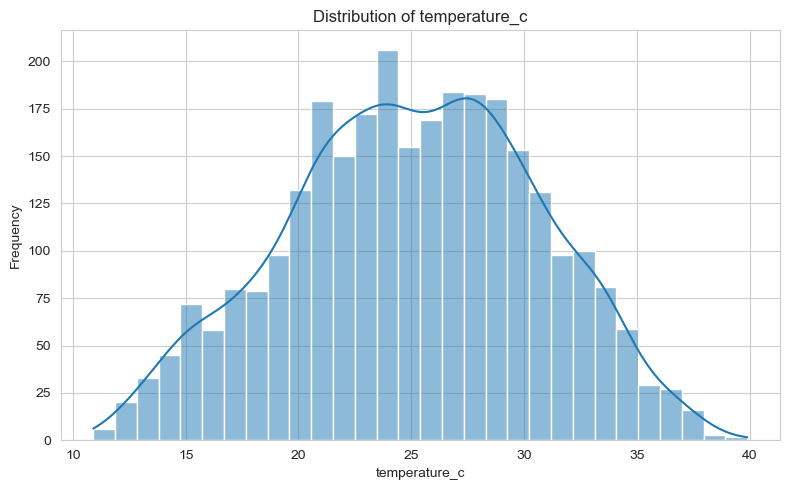

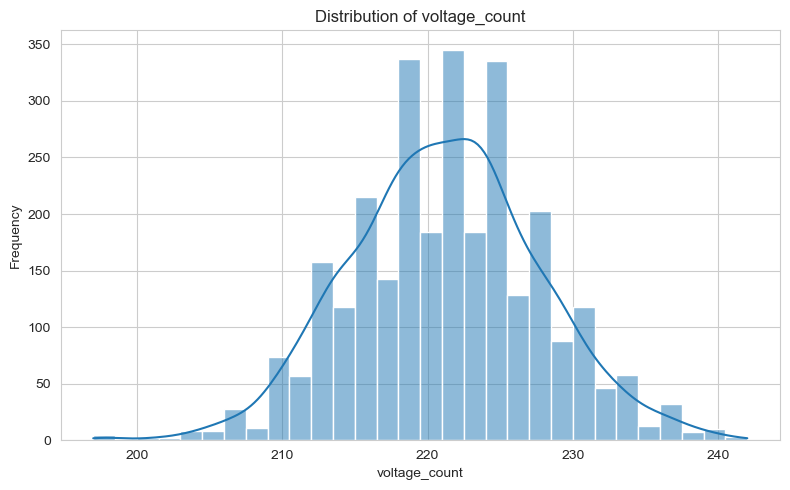

In [ ]:
# Histograms for numerical variables

for column in numerical_cols:
    plt.figure(figsize=(8,5))

    sns.histplot(df[column], bins=30, kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        f"charts/{column}_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

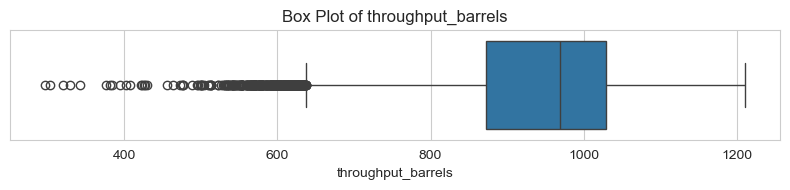

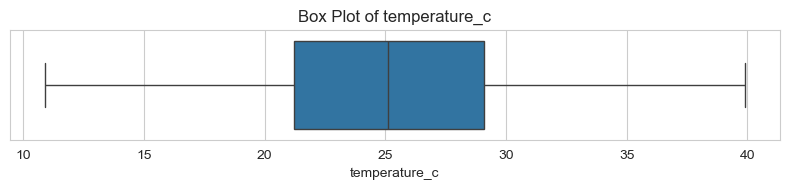

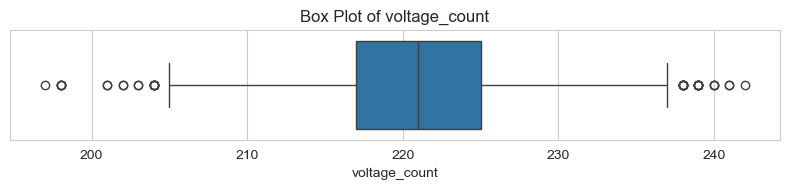

In [14]:
# Boxplots for numerical variables

for column in numerical_cols:
    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(f"Box Plot of {column}")

    plt.tight_layout()

    plt.savefig(
        f"charts/{column}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

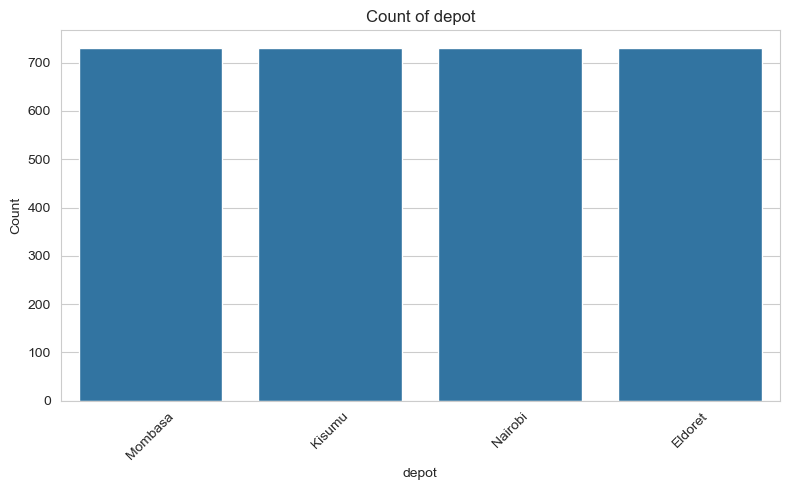

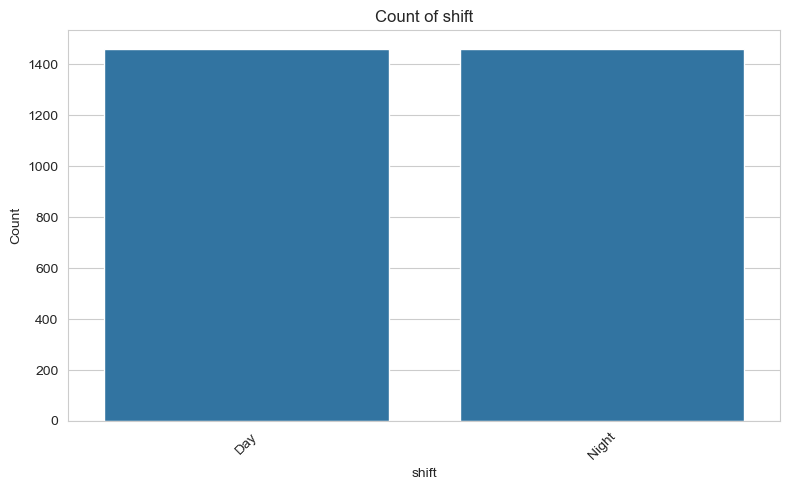

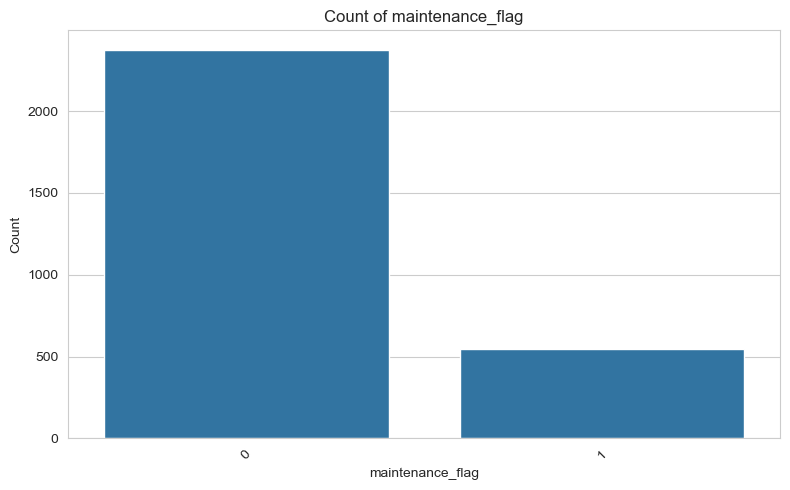

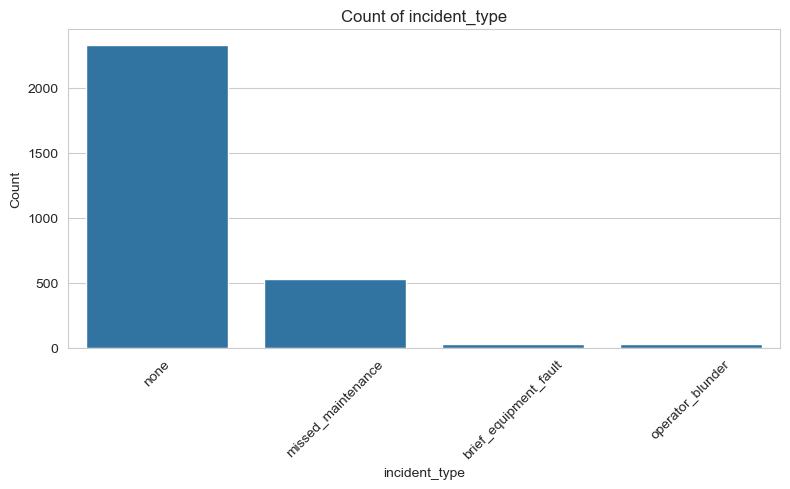

In [15]:
categorical_cols = [
    "depot",
    "shift",
    "maintenance_flag",
    "incident_type"
]

for column in categorical_cols:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Count of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(
        f"charts/{column}_countplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [16]:
for column in categorical_cols:

    print(f"\nFrequency Distribution: {column}")

    print(df[column].value_counts())

    print("-"*40)


Frequency Distribution: depot
depot
Mombasa    730
Kisumu     730
Nairobi    730
Eldoret    730
Name: count, dtype: int64
----------------------------------------

Frequency Distribution: shift
shift
Day      1460
Night    1460
Name: count, dtype: int64
----------------------------------------

Frequency Distribution: maintenance_flag
maintenance_flag
0    2375
1     545
Name: count, dtype: int64
----------------------------------------

Frequency Distribution: incident_type
incident_type
none                     2332
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
Name: count, dtype: int64
----------------------------------------


### Key Observations from the Univariate Analysis

The numerical variables show the overall distribution of operational performance metrics. The box plots indicate the presence of several unusually high and low observations, suggesting potential operational anomalies that require further investigation.

The categorical variables reveal differences in operational activity across depots, work shifts, maintenance status, and incident types. Some categories occur much more frequently than others, indicating possible operational patterns that will be explored further during the diagnostic analysis.

## 5. Bivariate Analysis

Bivariate analysis explores the relationships between two variables to identify patterns, trends, and potential operational drivers. These relationships provide the foundation for diagnosing operational issues and identifying possible root causes.

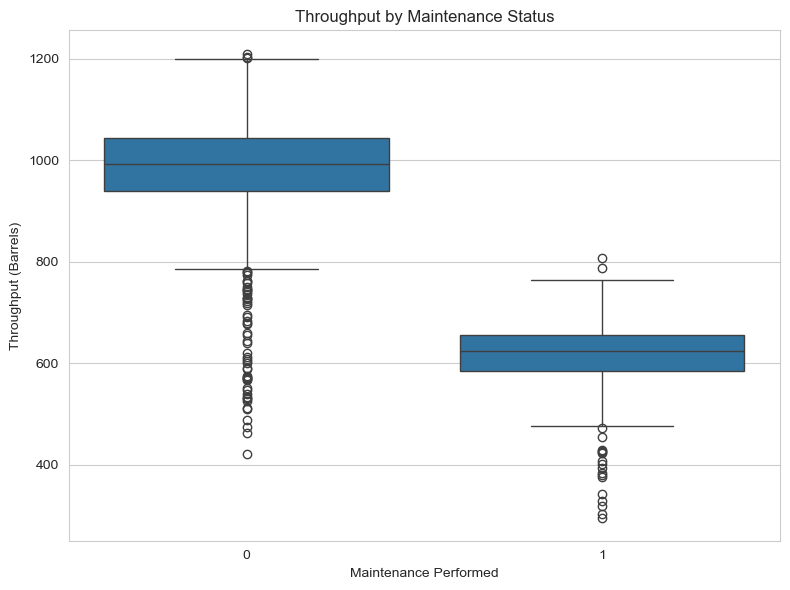

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="maintenance_flag",
    y="throughput_barrels"
)

plt.title("Throughput by Maintenance Status")
plt.xlabel("Maintenance Performed")
plt.ylabel("Throughput (Barrels)")

plt.tight_layout()

plt.savefig(
    "charts/throughput_by_maintenance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

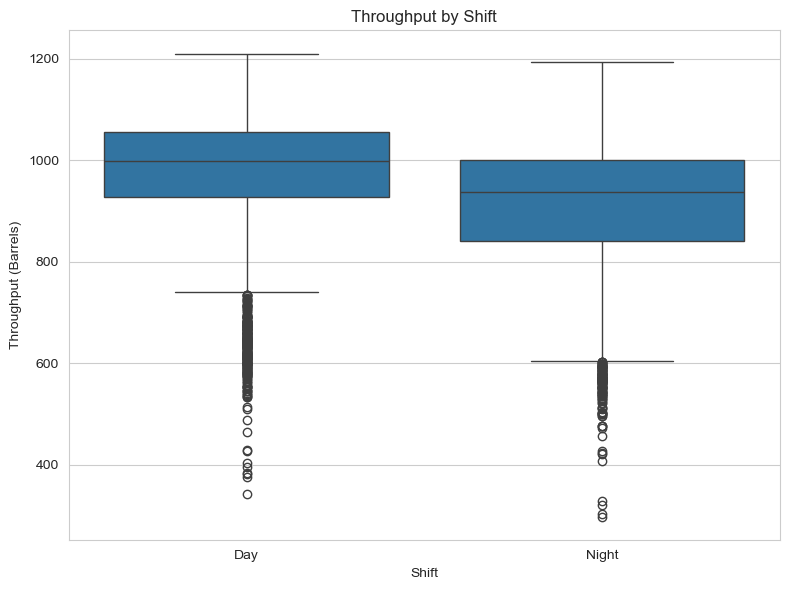

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="shift",
    y="throughput_barrels"
)

plt.title("Throughput by Shift")
plt.xlabel("Shift")
plt.ylabel("Throughput (Barrels)")

plt.tight_layout()

plt.savefig(
    "charts/throughput_by_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

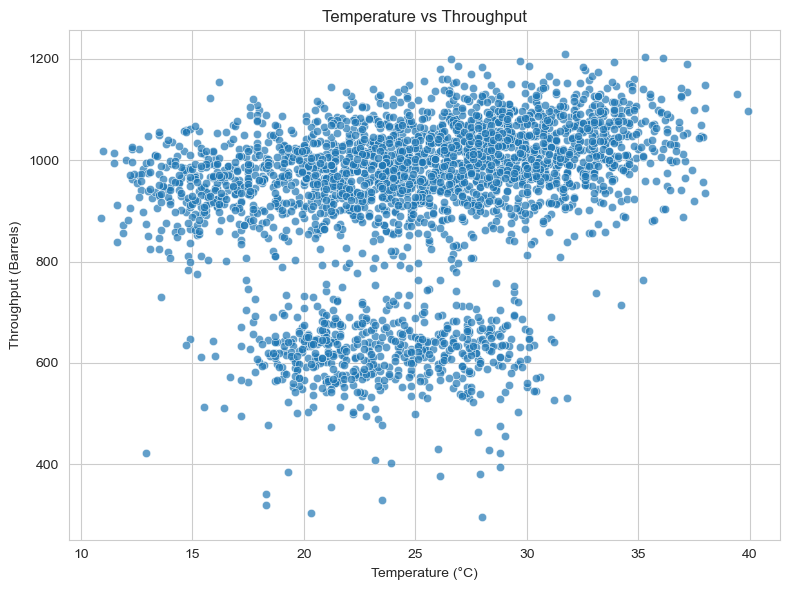

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="temperature_c",
    y="throughput_barrels",
    alpha=0.7
)

plt.title("Temperature vs Throughput")
plt.xlabel("Temperature (°C)")
plt.ylabel("Throughput (Barrels)")

plt.tight_layout()

plt.savefig(
    "charts/temperature_vs_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

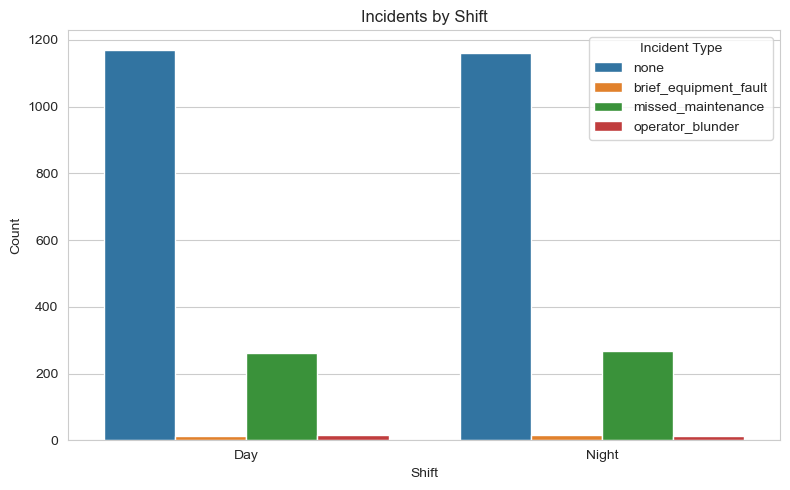

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="shift",
    hue="incident_type"
)

plt.title("Incidents by Shift")
plt.xlabel("Shift")
plt.ylabel("Count")

plt.legend(title="Incident Type")

plt.tight_layout()

plt.savefig(
    "charts/incidents_by_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings from the Bivariate Analysis

The bivariate analysis highlights several relationships that may influence operational performance. Throughput appears to vary across maintenance status, work shifts, and depots, suggesting that operational practices and location may affect production outcomes.

The scatter plot of temperature against throughput provides an initial indication of whether environmental conditions influence production efficiency. Additionally, the distribution of incidents across shifts helps identify whether operational issues are concentrated during specific working periods. These observations will be investigated further during the anomaly detection and root cause analysis stages.

## 6. Anomaly Detection

Anomaly detection identifies observations that differ significantly from the rest of the dataset. In operational environments, these unusual observations may indicate equipment faults, process inefficiencies, data quality issues, or exceptional operating conditions. Both visual and statistical methods are used to identify potential anomalies.

Lower Limit = Q1 − 1.5 × IQR

Upper Limit = Q3 + 1.5 × IQR

In [22]:
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"{column}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-"*40)

    return outliers

In [24]:
#Detect throughput outliers
throughput_outliers = detect_outliers(df, "throughput_barrels")

throughput_outliers.head()

throughput_barrels
Number of Outliers: 350
----------------------------------------


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
12,MO-20260402-ELD-N,02/04/2026,Eldoret,Night,OP-E02,ELD-P02,531.5,27.4,0,221,brief_equipment_fault
25,MO-20260417-NAI-N,17/04/2026,Nairobi,Night,OP-N04,NBI-P03,422.8,28.8,1,222,brief_equipment_fault
57,MO-20260512-NAI-N,12/05/2026,Nairobi,Night,OP-N05,NBI-P03,536.2,25.3,1,223,missed_maintenance
59,MO-20260421-MOM-N,21/04/2026,Mombasa,Night,OP-M04,MBA-P01,572.9,30.6,0,214,operator_blunder
60,MO-20260815-NAI-N,15/08/2026,Nairobi,Night,OP-N01,NBI-P03,568.1,24.1,1,238,missed_maintenance


In [25]:
#Detect temperature outliers
temperature_outliers = detect_outliers(df, "temperature_c")

temperature_outliers.head()

temperature_c
Number of Outliers: 0
----------------------------------------


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type


In [26]:
#Detect voltage outliers
voltage_outliers = detect_outliers(df, "voltage_count")

voltage_outliers.head()

voltage_count
Number of Outliers: 37
----------------------------------------


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
32,MO-20260601-NAI-D,01/06/2026,Nairobi,Day,OP-N03,NBI-P01,1123.0,25.7,0,241,none
60,MO-20260815-NAI-N,15/08/2026,Nairobi,Night,OP-N01,NBI-P03,568.1,24.1,1,238,missed_maintenance
69,MO-20260930-NAI-D,30/09/2026,Nairobi,Day,OP-N03,NBI-P03,656.4,20.2,1,238,missed_maintenance
538,MO-20261230-MOM-D,30/12/2026,Mombasa,Day,OP-M03,MBA-P03,1048.3,33.1,0,238,none
669,MO-20260413-ELD-N,13/04/2026,Eldoret,Night,OP-E01,ELD-P01,679.9,24.2,0,198,operator_blunder


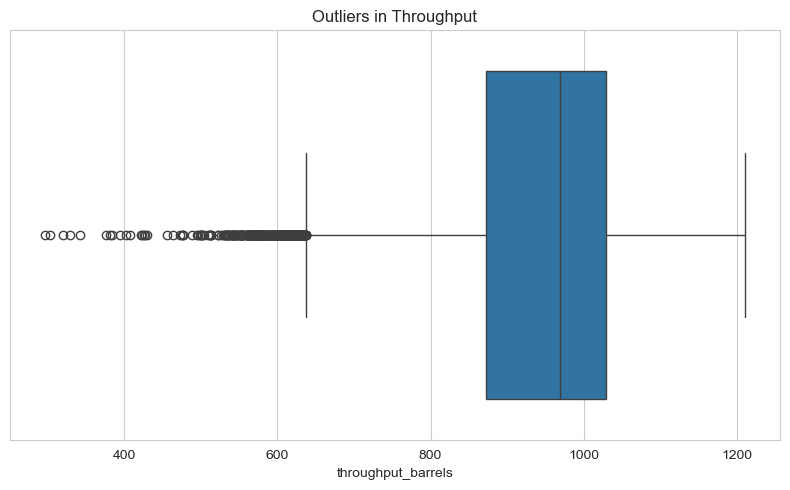

In [27]:
#Throughput
plt.figure(figsize=(8,5))

sns.boxplot(x=df["throughput_barrels"])

plt.title("Outliers in Throughput")

plt.tight_layout()

plt.savefig(
    "charts/outlier_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

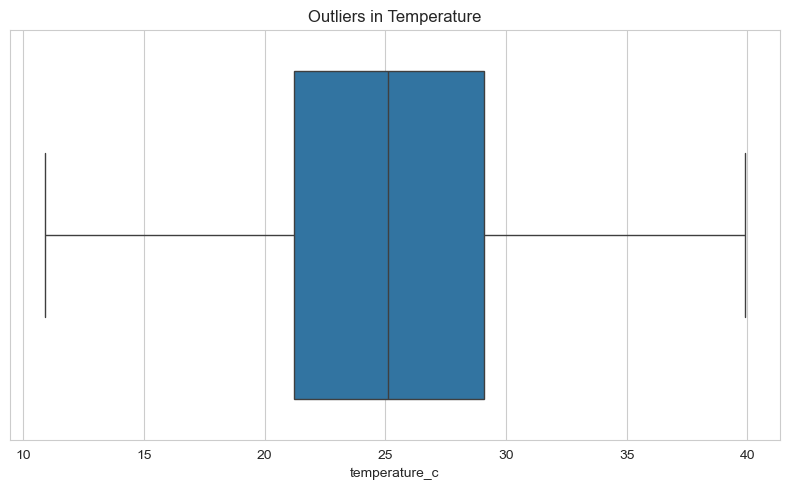

In [28]:
#Temperature
plt.figure(figsize=(8,5))

sns.boxplot(x=df["temperature_c"])

plt.title("Outliers in Temperature")

plt.tight_layout()

plt.savefig(
    "charts/outlier_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

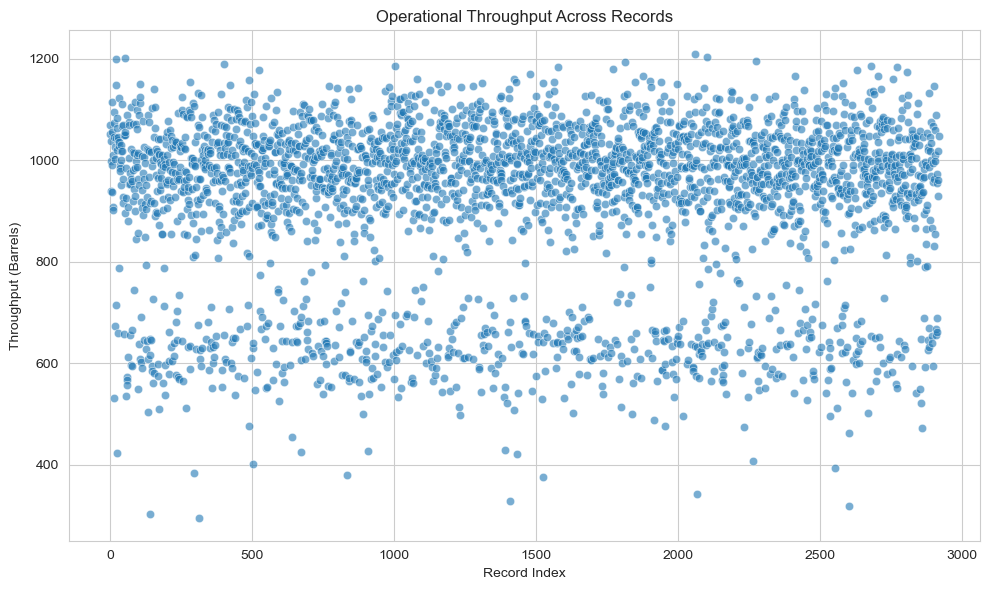

In [30]:
#Scatter plot highlighting outliers
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x=df.index,
    y="throughput_barrels",
    alpha=0.6
)

plt.title("Operational Throughput Across Records")

plt.xlabel("Record Index")

plt.ylabel("Throughput (Barrels)")

plt.tight_layout()

plt.savefig(
    "charts/throughput_scatter_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Findings from the Anomaly Detection

The anomaly detection process identified several observations that fall outside the expected operating range. These unusual values were detected using the Interquartile Range (IQR) method and confirmed visually using box plots and scatter plots.

Operational anomalies may represent periods of unusually high or low production, abnormal operating temperatures, or unexpected voltage readings. These records warrant further investigation to determine whether they reflect genuine operational issues, exceptional operating conditions, or potential data quality concerns.

The identified anomalies will be investigated further using drill-down analysis to determine where and under what operational conditions they occurred.

## 7. Root Cause Analysis

Root cause analysis aims to identify the underlying factors contributing to operational issues. Rather than simply describing what happened, this stage investigates where problems occur, what factors contribute to them, and which causes have the greatest operational impact.

The investigation uses:
- Drill-down analysis
- Pareto analysis
- Correlation analysis

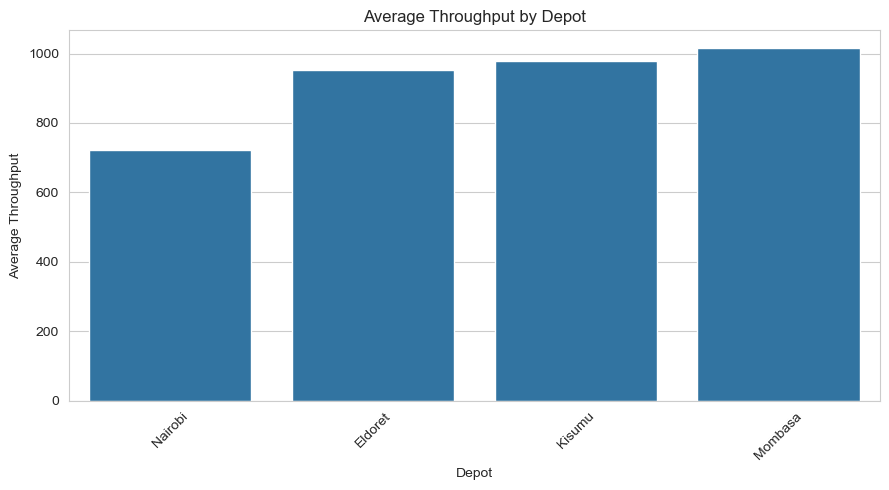

depot
Nairobi     721.305890
Eldoret     951.599589
Kisumu      979.234621
Mombasa    1015.851507
Name: throughput_barrels, dtype: float64

In [31]:
#Throughput by Depot
throughput_depot = (
    df.groupby("depot")["throughput_barrels"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=throughput_depot.index,
    y=throughput_depot.values
)

plt.title("Average Throughput by Depot")
plt.xlabel("Depot")
plt.ylabel("Average Throughput")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/drilldown_depot_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

throughput_depot

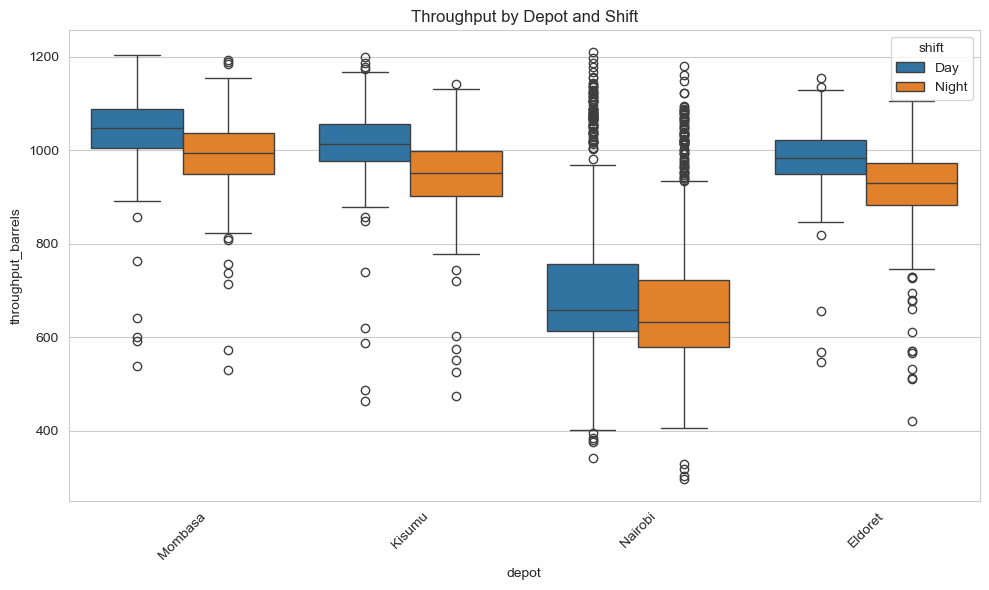

In [32]:
#Thoughput by shift and depot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="depot",
    y="throughput_barrels",
    hue="shift"
)

plt.title("Throughput by Depot and Shift")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/drilldown_depot_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

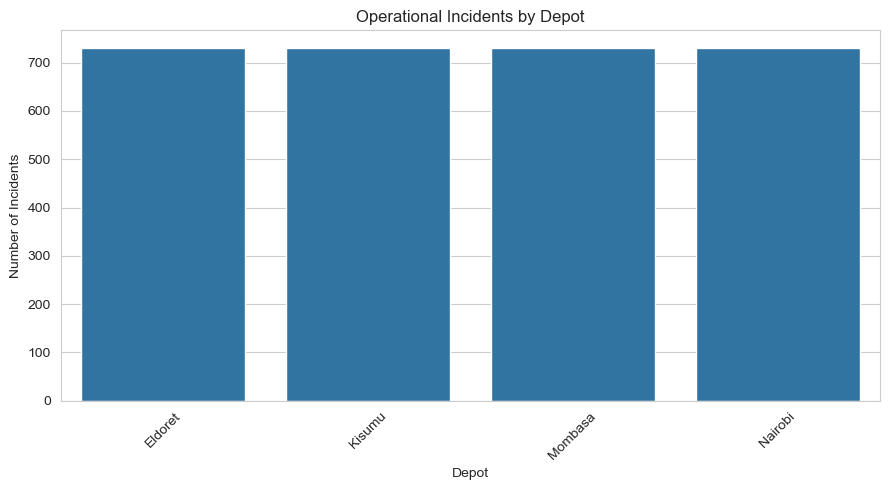

depot
Eldoret    730
Kisumu     730
Mombasa    730
Nairobi    730
Name: incident_type, dtype: int64

In [34]:
#Incidents by depot 
incident_counts = (
    df.groupby("depot")["incident_type"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=incident_counts.index,
    y=incident_counts.values
)

plt.title("Operational Incidents by Depot")
plt.xlabel("Depot")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/incidents_by_depot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

incident_counts

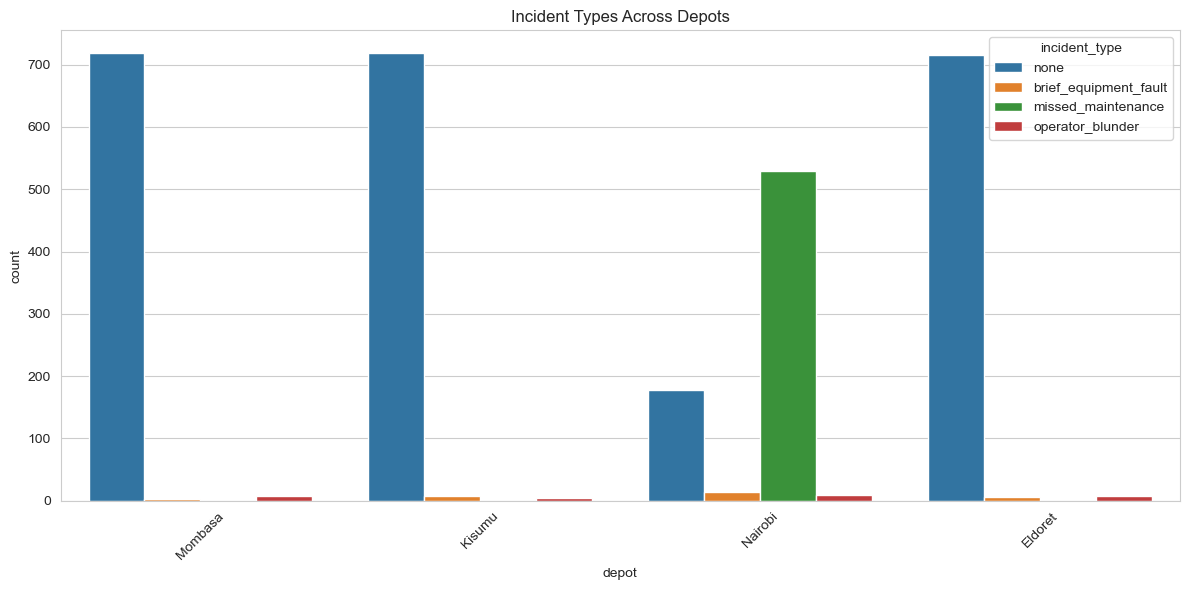

In [35]:
#Incident type by depot
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="depot",
    hue="incident_type"
)

plt.title("Incident Types Across Depots")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/incident_type_by_depot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

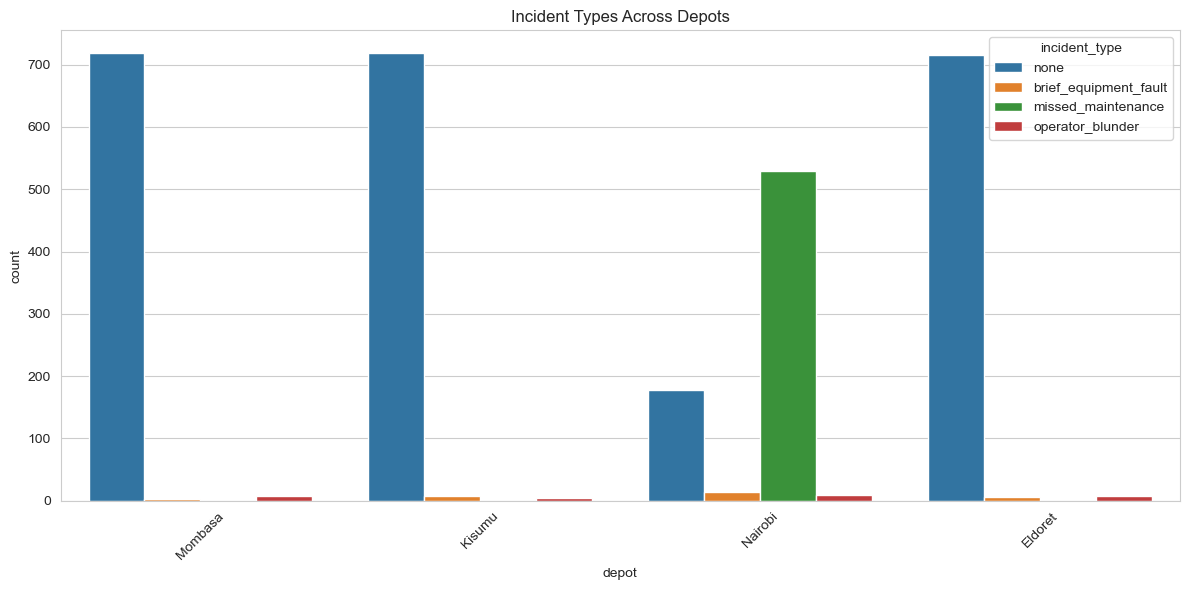

In [36]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="depot",
    hue="incident_type"
)

plt.title("Incident Types Across Depots")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/incident_type_by_depot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.2 Pareto Analysis

Pareto Analysis is used to identify the small number of causes responsible for the majority of operational issues. Applying the 80/20 principle helps prioritize improvement efforts by focusing on the most significant contributors to operational incidents.